# 03 — Cross-validation evaluation (substitute for ERA5)

Per-day **80/20 holdout cross-validation** at the station level: fit each
interpolation model on 80% of stations, predict at the held-out 20%, and
accumulate observed/predicted pairs across all evaluation dates. This is the
standard internal-validation approach for gridded climate products
(e.g., Hofstra et al., 2008) and substitutes for the missing ERA5 comparison.

Outputs:
- `figs/cv_table.csv`  — pooled RMSE & Pearson r per (variable, model)
- `figs/cv_per_station_<var>.csv` — per-station RMSE
- `figs/cv_map_<var>.png` — bubble map of per-station RMSE
- `figs/best_model_per_variable.csv` — recommendation


In [7]:
import sys, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pykrige.ok import OrdinaryKriging

warnings.filterwarnings('ignore')

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
from utils import CONUS_BBOX

TIDY = ROOT / 'data' / 'uscrn' / 'uscrn_daily_tidy.csv'
FIGS = ROOT / 'figs'; FIGS.mkdir(exist_ok=True)

df = pd.read_csv(TIDY, parse_dates=['date'])
print('rows:', len(df), '| stations:', df['station_id'].nunique())


rows: 47961 | stations: 132


## CV kernels (point predictions)

In [8]:
def idw_points(x, y, v, xq, yq, power=2, eps=1e-9):
    d = np.sqrt((xq[:, None] - x[None, :]) ** 2 + (yq[:, None] - y[None, :]) ** 2)
    w = 1.0 / (d ** power + eps)
    return (w * v[None, :]).sum(axis=1) / w.sum(axis=1)

def ok_points(x, y, v, xq, yq, model):
    OK = OrdinaryKriging(
        x, y, v, variogram_model=model,
        verbose=False, enable_plotting=False,
        nlags=12, weight=True,
    )
    z, _ = OK.execute('points', xq, yq)
    return np.asarray(z)


## 80/20 holdout CV per day

In [9]:
VARS = ['precip', 'rh', 't_air', 't_soil', 'sm']
MODELS = ['idw', 'spherical', 'exponential', 'gaussian']
HOLDOUT_FRAC = 0.2
MIN_STATIONS = 20
SEED = 42

records = []  # one row per (date, model, station, var)

for var in VARS:
    sub_all = df[['date', 'station_id', 'lon', 'lat', var]].dropna()
    sub_all = sub_all.rename(columns={var: 'val'})
    dates = sorted(sub_all['date'].unique())
    rng = np.random.default_rng(SEED)
    for d in tqdm(dates, desc=var):
        sub = sub_all.loc[sub_all['date'] == d]
        if len(sub) < MIN_STATIONS:
            continue
        idx = np.arange(len(sub)); rng.shuffle(idx)
        n_hold = max(1, int(round(HOLDOUT_FRAC * len(idx))))
        hold_i = idx[:n_hold]; train_i = idx[n_hold:]
        train = sub.iloc[train_i]; hold = sub.iloc[hold_i]
        xt, yt, vt = train['lon'].values, train['lat'].values, train['val'].values
        xh, yh, vh = hold['lon'].values, hold['lat'].values, hold['val'].values
        sids = hold['station_id'].values
        for m in MODELS:
            try:
                pred = idw_points(xt, yt, vt, xh, yh) if m == 'idw' \
                       else ok_points(xt, yt, vt, xh, yh, m)
            except Exception:
                pred = np.full_like(vh, np.nan, dtype=float)
            for sid, obs, p in zip(sids, vh, pred):
                records.append((var, m, str(d.date()), sid, obs, p))

cv = pd.DataFrame.from_records(records, columns=['variable','model','date','station_id','obs','pred'])
cv = cv.dropna()
print('cv rows:', len(cv))
cv.head()


precip:   0%|          | 0/366 [00:00<?, ?it/s]

rh:   0%|          | 0/366 [00:00<?, ?it/s]

t_air:   0%|          | 0/366 [00:00<?, ?it/s]

t_soil:   0%|          | 0/366 [00:00<?, ?it/s]

sm:   0%|          | 0/366 [00:00<?, ?it/s]

cv rows: 171604


,variable,model,date,station_id,obs,pred
0,precip,idw,2020-01-01,CO_Dinosaur_2_E,3.7,3.614473
1,precip,idw,2020-01-01,AL_Courtland_2_WSW,0.0,0.014572
2,precip,idw,2020-01-01,SD_Aberdeen_35_WNW,7.8,0.861500
3,precip,idw,2020-01-01,NE_Lincoln_8_ENE,0.0,0.058444
4,precip,idw,2020-01-01,WY_Lander_11_SSE,0.0,5.496848


## Pooled RMSE + Pearson r

In [10]:
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pearson(a, b):
    if a.size < 5: return np.nan
    return float(np.corrcoef(a, b)[0, 1])

pooled = (cv.groupby(['variable', 'model'])
            .apply(lambda g: pd.Series({
                'n': len(g),
                'rmse': rmse(g['pred'].values, g['obs'].values),
                'pearson_r': pearson(g['pred'].values, g['obs'].values),
            }))
            .reset_index())
pooled.to_csv(FIGS / 'cv_table.csv', index=False)
pooled


,variable,model,n,rmse,pearson_r
0,precip,exponential,9470.0,7.382953,0.542755
1,precip,gaussian,9470.0,165.878832,0.021523
2,precip,idw,9470.0,6.747540,0.641104
3,precip,spherical,9470.0,7.401280,0.539564
4,rh,exponential,8388.0,11.224584,0.853325
5,rh,gaussian,8388.0,13.053807,0.796035
6,rh,idw,8388.0,12.883286,0.810358
7,rh,spherical,8388.0,11.257960,0.852193
8,sm,exponential,7114.0,0.089981,0.646436
9,sm,gaussian,7114.0,0.088528,0.656460


In [11]:
best = pooled.loc[pooled.groupby('variable')['rmse'].idxmin()].reset_index(drop=True)
best.to_csv(FIGS / 'best_model_per_variable.csv', index=False)
best


,variable,model,n,rmse,pearson_r
0,precip,idw,9470.0,6.747540,0.641104
1,rh,exponential,8388.0,11.224584,0.853325
2,sm,spherical,7114.0,0.088457,0.657695
3,t_air,spherical,9515.0,2.943704,0.959880
4,t_soil,spherical,8414.0,3.982847,0.943256


## Per-station RMSE + bubble map

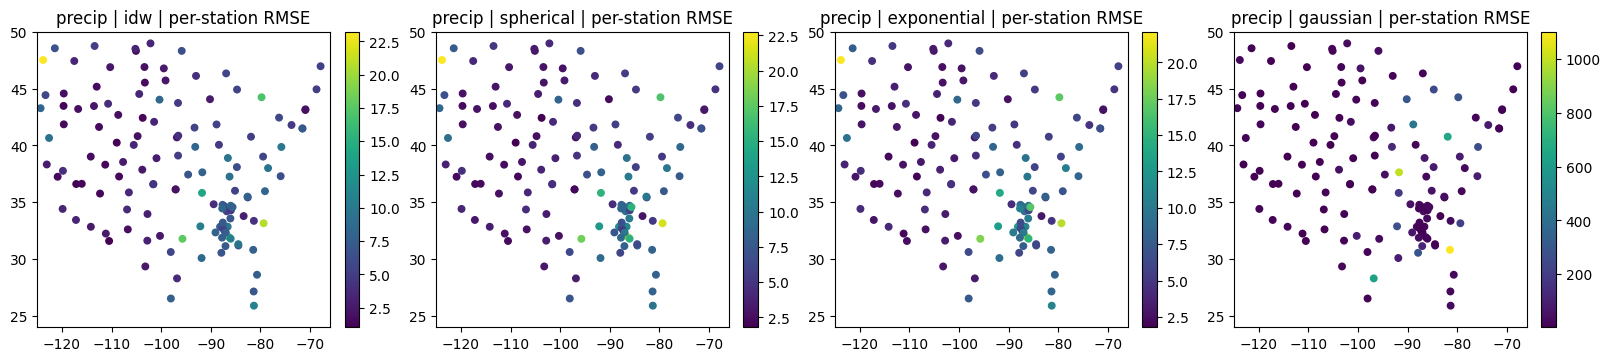

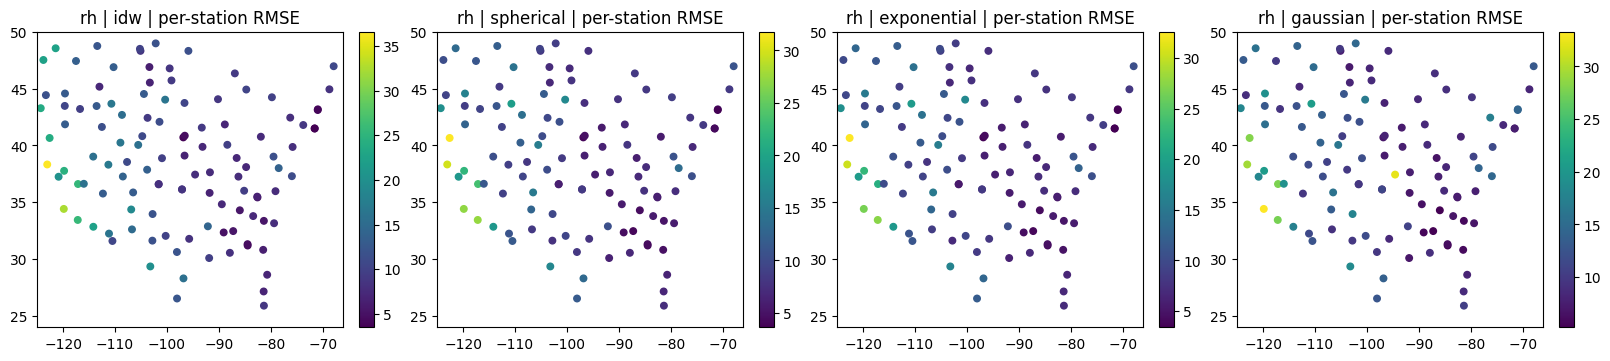

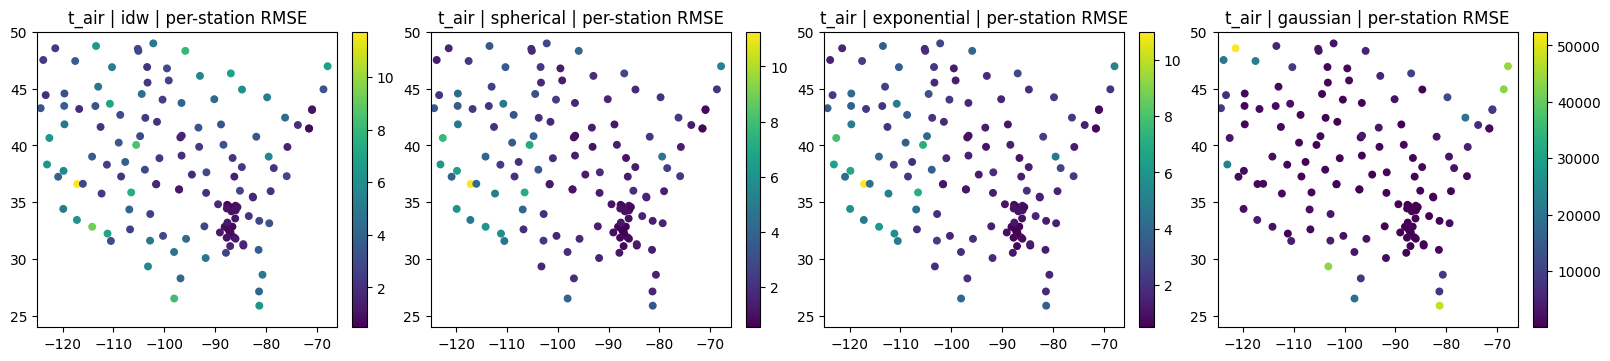

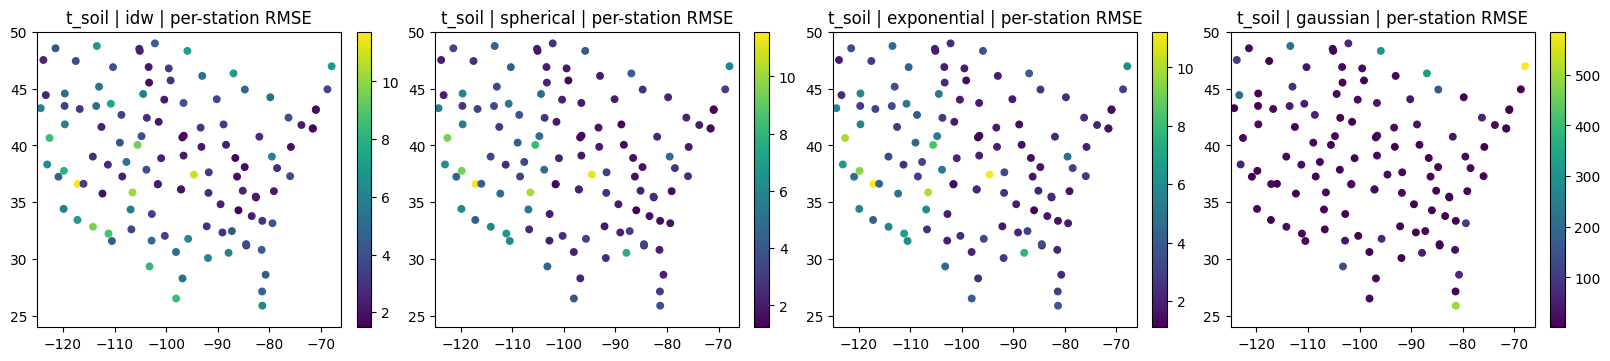

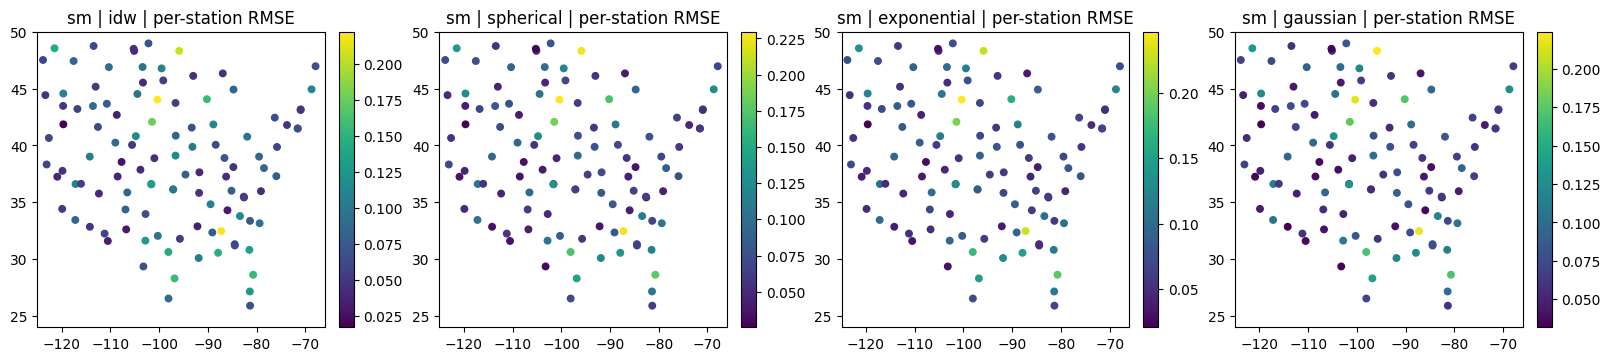

In [12]:
station_xy = df.groupby('station_id')[['lon', 'lat']].first()

for var in VARS:
    sub = cv[cv['variable'] == var]
    per = (sub.groupby(['station_id', 'model'])
              .apply(lambda g: rmse(g['pred'].values, g['obs'].values))
              .unstack('model'))
    per = per.join(station_xy)
    per.to_csv(FIGS / f'cv_per_station_{var}.csv')

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), constrained_layout=True)
    for ax, m in zip(axes, MODELS):
        s = ax.scatter(per['lon'], per['lat'], c=per[m], s=22, cmap='viridis')
        ax.set_title(f'{var} | {m} | per-station RMSE')
        ax.set_xlim(*CONUS_BBOX[:2]); ax.set_ylim(*CONUS_BBOX[2:])
        plt.colorbar(s, ax=ax)
    fig.savefig(FIGS / f'cv_map_{var}.png', dpi=120)
    plt.show()
